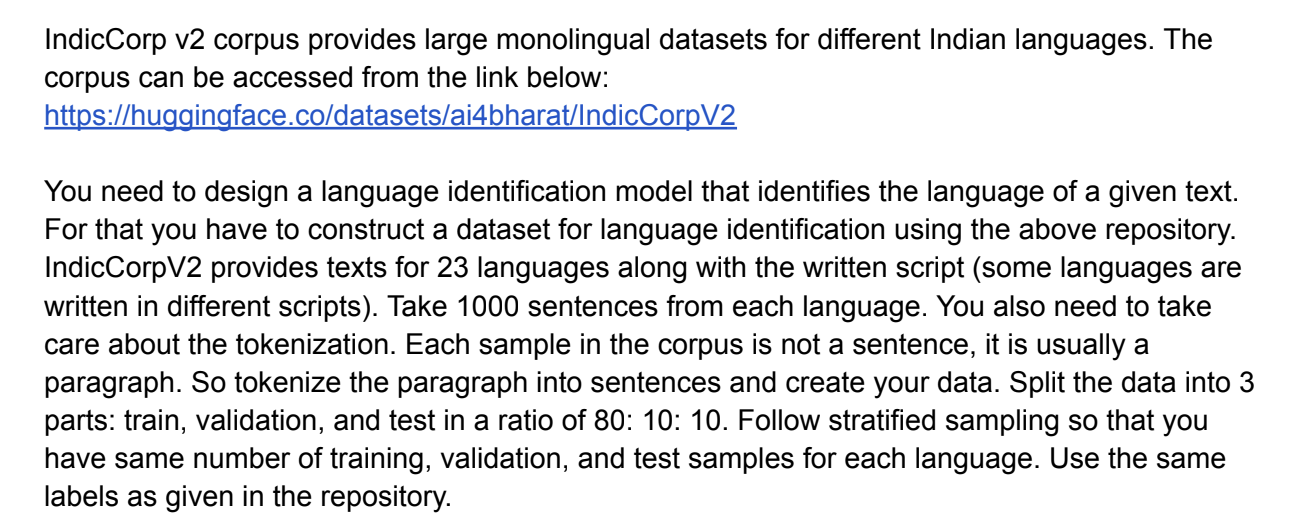

In [1]:
!pip install datasets scipy numpy tqdm

import re
import numpy as np
import scipy.sparse as sp
from datasets import load_dataset, get_dataset_config_names
from collections import defaultdict, Counter
from tqdm.notebook import tqdm
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 1.7 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 kB 1.1 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 1.0 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 825.2 kB/s  0:00:43m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [datasets]/17 [datasets]ce-hub]


/Users/adityakumar/Desktop/miniconda3/envs/DL/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from tqdm import tqdm
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 1.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]


In [7]:
dataset_name = "ai4bharat/IndicCorpV2"

# Use the exact 23 split names provided by the dataset's architecture
languages = [
    'asm_Beng', 'ben_Beng', 'brx_Deva', 'doi_Deva', 'gom_Deva', 
    'guj_Gujr', 'hin_Deva', 'kan_Knda', 'kas_Arab', 'mai_Deva', 
    'mal_Mlym', 'mar_Deva', 'mni_Mtei', 'npi_Deva', 'ory_Orya', 
    'pan_Guru', 'san_Deva', 'snd_Deva', 'tam_Taml', 'tel_Telu', 
    'urd_Arab', 'khasi', 'santhali'
]

train_data, val_data, test_data = [], [], []
train_labels, val_labels, test_labels = [], [], []

# Regex to split paragraphs into sentences based on standard and Indic punctuation
split_pattern = re.compile(r'[।!?.\n]+')

def get_sentences(text):
    sentences = split_pattern.split(text)
    # Filter out empty strings and extremely short noisy sentences
    return [s.strip() for s in sentences if len(s.strip()) > 15]

print(f"Fetching data for {len(languages)} languages. This will take a few minutes...")

for lang_idx, lang_split in enumerate(tqdm(languages, desc="Processing Languages")):
    # Fix: Pass the language directly as the 'split' argument instead of 'train'
    dataset = load_dataset(dataset_name, split=lang_split, streaming=True)
    
    lang_sentences = []
    
    for sample in dataset:
        text = sample['text']
        sentences = get_sentences(text)
        
        for sent in sentences:
            if len(lang_sentences) < 1000:
                lang_sentences.append(sent)
            else:
                break
        
        if len(lang_sentences) == 1000:
            break
            
    # Stratified Split: 800 Train, 100 Val, 100 Test
    train_data.extend(lang_sentences[:800])
    train_labels.extend([lang_idx] * 800)
    
    val_data.extend(lang_sentences[800:900])
    val_labels.extend([lang_idx] * 100)
    
    test_data.extend(lang_sentences[900:1000])
    test_labels.extend([lang_idx] * 100)

print(f"Total Training Samples: {len(train_data)}")
print(f"Total Validation Samples: {len(val_data)}")
print(f"Total Test Samples: {len(test_data)}")

Fetching data for 23 languages. This will take a few minutes...


Exception ignored in: <function tqdm.__del__ at 0x303d1afc0>
Traceback (most recent call last):
  File "/Users/adityakumar/Desktop/miniconda3/envs/DL/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/adityakumar/Desktop/miniconda3/envs/DL/lib/python3.11/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Processing Languages: 100%|██████████| 23/23 [03:05<00:00,  8.08s/it]

Total Training Samples: 18400
Total Validation Samples: 2300
Total Test Samples: 2300


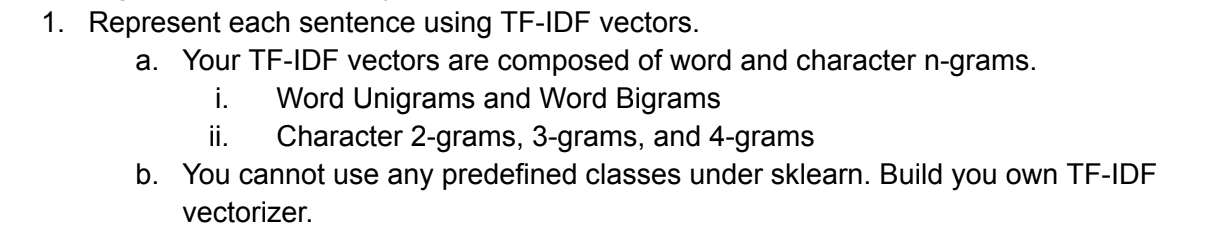

In [ ]:
class CustomTFIDF:
    def __init__(self, min_df=3):
        self.min_df = min_df
        self.vocab = {}
        self.idf = {}
        
    def extract_ngrams(self, text):
        words = text.split()
        ngrams = []
        
        # Word Unigrams
        ngrams.extend(words)
        # Word Bigrams
        ngrams.extend([f"{words[i]}_{words[i+1]}" for i in range(len(words)-1)])
        
        # Character 2, 3, and 4-grams
        text_no_space = text.replace(" ", "")
        for n in [2, 3, 4]:
            ngrams.extend([text_no_space[i:i+n] for i in range(len(text_no_space)-n+1)])
            
        return ngrams

    def fit(self, documents):
        print("Building vocabulary and calculating DF...")
        doc_freq = Counter()
        
        for doc in tqdm(documents, desc="Fitting TF-IDF"):
            ngrams = set(self.extract_ngrams(doc)) # Unique ngrams per doc for DF
            for ngram in ngrams:
                doc_freq[ngram] += 1
                
        # Filter vocabulary based on min_df to save memory
        vocab_idx = 0
        N = len(documents)
        for ngram, freq in doc_freq.items():
            if freq >= self.min_df:
                self.vocab[ngram] = vocab_idx
                # Calculate IDF
                self.idf[ngram] = math.log((N + 1) / (freq + 1)) + 1
                vocab_idx += 1
                
        print(f"Vocabulary size: {len(self.vocab)}")
    #converting into matrix of tf-idf scores
    def transform(self, documents):
        print("Transforming documents to TF-IDF sparse matrix...")
        rows, cols, data = [], [], []
        
        for row_idx, doc in enumerate(tqdm(documents, desc="Transforming")):
            ngrams = self.extract_ngrams(doc)
            term_freq = Counter(ngrams)
            
            for ngram, count in term_freq.items():
                if ngram in self.vocab:
                    col_idx = self.vocab[ngram]
                    # TF calculation (raw count)
                    tf = count
                    # TF-IDF
                    tfidf_val = tf * self.idf[ngram]
                    
                    rows.append(row_idx)
                    cols.append(col_idx)
                    data.append(tfidf_val)
                    
        # Create Sparse Matrix (CSR format is efficient for math operations)
        sparse_mat = sp.csr_matrix((data, (rows, cols)), shape=(len(documents), len(self.vocab)))
        
        # L2 Normalization (improves Logistic Regression convergence)
        norms = np.array(sp.linalg.norm(sparse_mat, axis=1)).flatten()
        norms[norms == 0] = 1 # Avoid division by zero
        sparse_mat = sparse_mat.multiply(1 / norms[:, np.newaxis])
        
        return sparse_mat

# Initialize and transform data
vectorizer = CustomTFIDF(min_df=5) 
vectorizer.fit(train_data)

X_train = vectorizer.transform(train_data)
X_val = vectorizer.transform(val_data)
X_test = vectorizer.transform(test_data)

y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(test_labels)

Building vocabulary and calculating DF...


Fitting TF-IDF: 100%|██████████| 18400/18400 [00:01<00:00, 15688.88it/s]


Vocabulary size: 132377
Transforming documents to TF-IDF sparse matrix...


Transforming: 100%|██████████| 18400/18400 [00:00<00:00, 21506.91it/s]


Transforming documents to TF-IDF sparse matrix...


Transforming: 100%|██████████| 2300/2300 [00:00<00:00, 20096.62it/s]


Transforming documents to TF-IDF sparse matrix...


Transforming: 100%|██████████| 2300/2300 [00:00<00:00, 21296.90it/s]


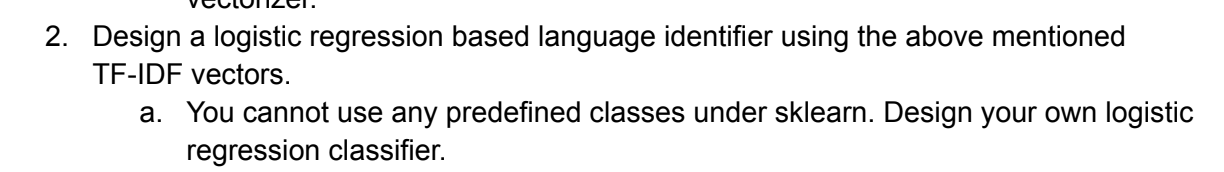

In [10]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.1, epochs=50, batch_size=256, num_classes=23):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.weights = None
        self.bias = None
        
    def softmax(self, z):
        # Subtract max for numerical stability
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
        
    def fit(self, X, y):
        num_samples, num_features = X.shape
        self.weights = np.zeros((num_features, self.num_classes))
        self.bias = np.zeros(self.num_classes)
        
        # One-hot encode labels
        y_one_hot = np.zeros((num_samples, self.num_classes))
        y_one_hot[np.arange(num_samples), y] = 1
        
        for epoch in range(self.epochs):
            # Shuffle data
            indices = np.arange(num_samples)
            np.random.shuffle(indices)
            
            epoch_loss = 0
            
            for i in range(0, num_samples, self.batch_size):
                batch_indices = indices[i:i + self.batch_size]
                X_batch = X[batch_indices]
                y_batch = y_one_hot[batch_indices]
                
                # Forward pass
                linear_model = X_batch.dot(self.weights) + self.bias
                predictions = self.softmax(linear_model)
                
                # Compute loss (Cross Entropy)
                loss = -np.mean(np.sum(y_batch * np.log(predictions + 1e-9), axis=1))
                epoch_loss += loss
                
                # Backward pass (Gradients)
                dz = predictions - y_batch
                dw = (X_batch.T.dot(dz)) / self.batch_size
                db = np.sum(dz, axis=0) / self.batch_size
                
                # Update parameters
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
                
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1}/{self.epochs} - Loss: {epoch_loss / (num_samples/self.batch_size):.4f}")
                
    def predict(self, X):
        linear_model = X.dot(self.weights) + self.bias
        predictions = self.softmax(linear_model)
        return np.argmax(predictions, axis=1)

# Convert back to CSR format for fast row slicing
X_train = X_train.tocsr()
X_val = X_val.tocsr()
X_test = X_test.tocsr()

# Train the model
model = CustomLogisticRegression(learning_rate=0.5, epochs=100, batch_size=512, num_classes=len(languages))
print("Training Custom Logistic Regression...")
model.fit(X_train, y_train)

Training Custom Logistic Regression...
Epoch 10/100 - Loss: 2.6706
Epoch 20/100 - Loss: 2.2412
Epoch 30/100 - Loss: 1.8971
Epoch 40/100 - Loss: 1.6310
Epoch 50/100 - Loss: 1.4262
Epoch 60/100 - Loss: 1.2667
Epoch 70/100 - Loss: 1.1404
Epoch 80/100 - Loss: 1.0385
Epoch 90/100 - Loss: 0.9546
Epoch 100/100 - Loss: 0.8847


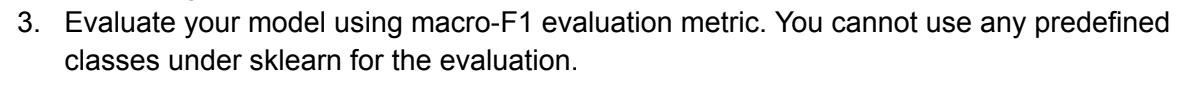

In [11]:
def macro_f1_score(y_true, y_pred, num_classes):
    f1_scores = []
    
    for c in range(num_classes):
        # True Positives, False Positives, False Negatives
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        
        if precision + recall > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0.0
            
        f1_scores.append(f1)
        
    return np.mean(f1_scores)

# Evaluate on Validation Data
val_preds = model.predict(X_val)
val_f1 = macro_f1_score(y_val, val_preds, len(languages))
print(f"Validation Macro-F1 Score: {val_f1:.4f}")

# Evaluate on Test Data
test_preds = model.predict(X_test)
test_f1 = macro_f1_score(y_test, test_preds, len(languages))
print(f"Test Macro-F1 Score: {test_f1:.4f}")

Validation Macro-F1 Score: 0.9293
Test Macro-F1 Score: 0.9406
